# Automated Acoustic Side-Channel Attack on Keyboard Inputs

Notebook reproducing the full pipeline described in the paper. Sections:

1. **Data collection & labelling** — click detection + cropping (paper Sec. 3.4)
2. **Feature extraction** — log-mel spectrograms + SpecAugment (paper Sec. 3.1 / 3.5)
3. **Hyperparameter grid search** — CNN configs, Tables 2-3 (paper Sec. 3.8)
4. **Base CNN model** — Stratified 5-fold CV + Top-k accuracy + entropy reduction
   (paper Sec. 3.2 / 3.6 / 4.2-4.4)
5. **Transfer learning** — freeze backbone, retrain head on a few samples (paper Sec. 3.7 / 4.3)
6. **Test on unseen data** — qualitative per-key predictions

## 0. Setup

In [1]:
# Raw keystroke recordings + the cropped datasets used in the paper.
#   sounds_folder/        -> raw per-key recordings (cropped on the fly below)
#   cropped_base/         -> 125-keytaps-per-key base dataset (Cropped_Keystrokes_marin2)
!git clone https://github.com/k3rnel-pan1c-ksd/input-sounds.git

Cloning into 'input-sounds'...
remote: Enumerating objects: 8470, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 8470 (delta 2), reused 0 (delta 0), pack-reused 8466 (from 3)
Receiving objects: 100% (8470/8470), 447.32 MiB | 31.16 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Updating files: 100% (8428/8428), done.


In [2]:
!pip3 -q install resampy visualkeras pydot
!apt-get -qq install -y graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.8 MB/s eta 0:00:00


In [3]:
import os
import re
import wave
import struct
from datetime import datetime
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Flatten
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

try:
    from tensorflow.keras.utils import plot_model
except Exception:
    plot_model = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
print("TensorFlow", tf.__version__)

TensorFlow 2.20.0


## 1. Data collection & labelling (click detection + cropping)

Following *Don't Skype & Type!*, each recording is scanned for high-energy
press events; a window around every detected click is cropped and stored as an
individual `<key>_<index>.wav` file (paper Sec. 3.4).

In [4]:
def get_top_amplitudes_with_spacing(audio_data, num_amplitudes=10,
                                    min_spacing_seconds=0.5, sample_rate=44100):
    min_spacing_samples = int(min_spacing_seconds * sample_rate)
    sorted_indices = np.argsort(audio_data)[::-1]  # descending amplitude
    top_indices = []
    prev_indices = []
    for index in sorted_indices:
        if all(abs(index - prev_index) >= min_spacing_samples for prev_index in prev_indices):
            top_indices.append(index)
            prev_indices.append(index)
            if len(top_indices) == num_amplitudes:
                break
    return top_indices

In [5]:
def detectKeyPresses(num_amplitudes, input_wav_file, output_directory, isUnseen):
    # 32-bit PCM -> 2^31 full scale
    maxInt = 2147483648

    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    wav = wave.open(input_wav_file, 'r')
    frames = wav.readframes(-1)
    signal = np.array(struct.unpack('i' * wav.getnframes(), frames))
    audio_data = signal / maxInt
    sample_rate = wav.getframerate()

    key_event_indices = get_top_amplitudes_with_spacing(
        audio_data, num_amplitudes, min_spacing_seconds=0.110, sample_rate=sample_rate)
    timestamps_ms = [int(1000 * index / sample_rate) for index in key_event_indices]

    trim_before_ms = 50   # 0.05 s before the click
    trim_after_ms = 200   # 0.20 s after the click

    counter = 0
    for timestamp_ms in sorted(timestamps_ms):
        start_index = int((timestamp_ms - trim_before_ms) * sample_rate / 1000)
        end_index = int((timestamp_ms + trim_after_ms) * sample_rate / 1000)
        trimmed_audio = audio_data[start_index:end_index]

        counter += 1
        if isUnseen:
            output_file = f'{output_directory}/unseen_{counter}.wav'
        else:
            key = re.search(r'/([^/]+)\.wav$', input_wav_file).group(1)
            output_file = f'{output_directory}/{key}_{counter}.wav'

        with wave.open(output_file, 'w') as output_wav:
            output_wav.setnchannels(1)
            output_wav.setsampwidth(4)
            output_wav.setframerate(sample_rate)
            output_wav.writeframes(
                struct.pack('i' * len(trimmed_audio), *map(int, trimmed_audio * maxInt)))

In [6]:
# Crop every raw recording into individual keystroke files.
# Set to False if your repo already ships the cropped target wavs.
RUN_CROPPING = True

folder_path = "input-sounds/sounds_folder"
if RUN_CROPPING and os.path.exists(folder_path):
    for filename in os.listdir(folder_path):
        detectKeyPresses(25, f"{folder_path}/{filename}", "input_sounds_cropped", isUnseen=False)
    print("Cropped files written to input_sounds_cropped/")
elif not RUN_CROPPING:
    print("Skipping cropping (RUN_CROPPING=False).")
else:
    print("Invalid folder path:", folder_path)

Cropped files written to input_sounds_cropped/


## 2. Feature extraction (log-mel spectrogram + SpecAugment)

64 mel bands, 1024-sample FFT window (~23 ms), 225-sample hop (~5 ms), converted
to dB. SpecAugment masks 1-2 frequency and 1-2 time bands (replaced by the global
mean) to improve generalisation (paper Sec. 3.1 / 3.5).

In [7]:
def spec_augment(mel_spectrogram):
    """Moderate SpecAugment: 1-2 frequency masks and 1-2 time masks (1-4 bands each)."""
    mel_spectrogram = mel_spectrogram.copy()
    num_freqs, num_frames = mel_spectrogram.shape
    mean_value = mel_spectrogram.mean()

    for _ in range(np.random.randint(1, 3)):
        if num_freqs > 4:
            freq_band = np.random.randint(1, 5)
            freq_base = np.random.randint(0, num_freqs - freq_band + 1)
            mel_spectrogram[freq_base:freq_base + freq_band, :] = mean_value

    for _ in range(np.random.randint(1, 3)):
        if num_frames > 4:
            time_band = np.random.randint(1, 5)
            time_base = np.random.randint(0, num_frames - time_band + 1)
            mel_spectrogram[:, time_base:time_base + time_band] = mean_value

    return mel_spectrogram


def extract_features(file_path, use_augment=False):
    """Log-mel spectrogram for one wav; optional SpecAugment."""
    mel_bands = 64
    fft_window_size = 1024
    hop_length = 225

    audio_signal, sample_rate = librosa.load(file_path, sr=None)
    mel_spec = librosa.feature.melspectrogram(
        y=audio_signal, sr=sample_rate,
        n_fft=fft_window_size, hop_length=hop_length, n_mels=mel_bands)
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)

    if use_augment:
        log_mel = spec_augment(log_mel)
    return log_mel

In [8]:
# 47-key alphabet of the cropped dataset (Croatian QWERTZ).
# Kept for reference / fixed ordering; load_dataset auto-discovers classes by
# default so datasets with a different key set (e.g. the 67-key base dataset)
# load without edits.
CLASSES = [
    "space", "1", "2", "3", "4", "5", "6", "7", "8", "9", "0", "minus", "jednako",
    "q", "w", "e", "r", "t", "y", "u", "i", "o", "p", "[", "]", "backSlash",
    "a", "s", "d", "f", "g", "h", "j", "k", "L", "tockaZarez", "jednostrukiNavodnik",
    "z", "x", "c", "v", "b", "n", "m", "zarez", "tocka", "frontSlash",
]


def load_dataset(folder, classes=None, samples_per_key=None, use_augment=False):
    """Load log-mel features and one-hot labels from a folder of cropped wavs.

    Files are expected as `<class>_<idx>.wav`. Classes are auto-discovered from
    the filenames unless an explicit `classes` list is passed. Pass
    `samples_per_key` to cap how many samples per key are loaded (None = all).
    A regex parser is used so class names containing `[` / `]` are handled.
    """
    by_label = {}
    for fn in os.listdir(folder):
        m = re.match(r"^(.*)_(\d+)\.wav$", fn)
        if not m:
            continue
        by_label.setdefault(m.group(1), []).append((int(m.group(2)), fn))

    if classes is None:
        classes = sorted(by_label)

    features, labels = [], []
    for label in classes:
        items = sorted(by_label.get(label, []))
        if samples_per_key is not None:
            items = items[:samples_per_key]
        for _, fn in items:
            features.append(extract_features(os.path.join(folder, fn), use_augment=use_augment))
            labels.append(label)

    X = np.array(features, dtype=np.float32)
    y = np.array(labels)
    freq_bins, time_bins = X.shape[1], X.shape[2]
    X = X.reshape((-1, freq_bins, time_bins, 1))

    le = LabelEncoder()
    y_onehot = to_categorical(le.fit_transform(y))
    num_classes = len(le.classes_)
    print(f"Loaded {X.shape[0]} samples | shape {X.shape[1:]} | {num_classes} classes from {folder}")
    return X, y_onehot, le, (freq_bins, time_bins, num_classes)

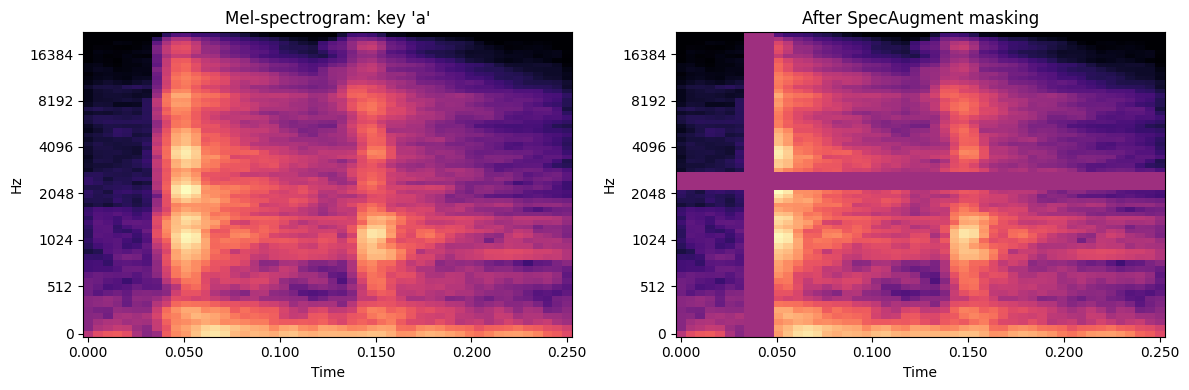

In [9]:
# Visual sanity check: a mel-spectrogram and its SpecAugment-masked version
# (paper Figures 4 and 5).
sample = "input_sounds_cropped/a_1.wav"
if os.path.exists(sample):
    mel = extract_features(sample, use_augment=False)
    masked = spec_augment(mel.copy())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    librosa.display.specshow(mel, x_axis="time", y_axis="mel",
                             sr=44100, hop_length=225, ax=axes[0])
    axes[0].set_title("Mel-spectrogram: key 'a'")
    librosa.display.specshow(masked, x_axis="time", y_axis="mel",
                             sr=44100, hop_length=225, ax=axes[1])
    axes[1].set_title("After SpecAugment masking")
    plt.tight_layout()
    plt.show()
else:
    print("Run Section 1 first to generate cropped wavs.")

## 3. CNN architecture (paper Sec. 3.2)

Two convolutional blocks of factored convolutions (3x3, then 3x1 and 1x3) that
decouple temporal and spectral feature learning, `same` padding, no bias in the
first block, `(2x1)` max-pooling to compress time while preserving frequency
resolution, dropout, a dense layer with batch-norm, and a softmax head.

In [10]:
def build_cnn(input_shape, num_classes, filters=(32, 64), dense_units=256,
              dropout_conv=0.2, dropout_dense=0.4, lr=1e-3):
    """Paper CNN. `filters` = (block1, block2) channel counts."""
    f1, f2 = filters

    model = Sequential()
    model.add(tf.keras.Input(shape=input_shape))

    # Block 1: factored convolutions, no bias.
    model.add(Conv2D(f1, (3, 3), activation="relu", padding="same", use_bias=False))
    model.add(Conv2D(f1, (3, 1), activation="relu", padding="same", use_bias=False))
    model.add(Conv2D(f1, (1, 3), activation="relu", padding="same", use_bias=False))
    model.add(MaxPooling2D((2, 1)))

    # Block 2: more channels.
    model.add(Conv2D(f2, (3, 3), activation="relu", padding="same"))
    model.add(Conv2D(f2, (3, 1), activation="relu", padding="same"))
    model.add(Conv2D(f2, (1, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D((2, 1)))

    model.add(Dropout(dropout_conv))
    model.add(Flatten())
    model.add(Dense(dense_units, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_dense))
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def top_k_accuracy(y_true, y_pred_probs, k=3):
    """Top-k accuracy for one-hot labels and probability predictions."""
    y_true_labels = np.argmax(y_true, axis=1)
    top_k = np.argsort(y_pred_probs, axis=1)[:, -k:]
    return float(np.mean([t in top_k[i] for i, t in enumerate(y_true_labels)]))

### 3.1 Hyperparameter grid search (Tables 2-3)

Grid over filters `{(32,64),(64,64),(64,128)}`, dense units `{128,256}`, dense
dropout `{0.3,0.4,0.5}` and learning rate `{1e-3,3e-4,1e-4}` (conv dropout fixed
at 0.2) = 54 configurations, ranked by validation macro-F1. Writes
`hyperparam_results.csv` and the best-config training curves.

> Runtime note: 54 configs x up to 50 epochs. Skip this cell if you already have
> `hyperparam_results.csv`; Section 4 reads the best row from that file.

Loaded 1175 samples | shape (64, 50, 1) | 47 classes from input_sounds_cropped
Total configurations: 54
cfg  1/54 | (32, 64) d128 dd0.3 lr0.001 | val_f1=0.9739
cfg  2/54 | (32, 64) d128 dd0.3 lr0.0003 | val_f1=0.9568
cfg  3/54 | (32, 64) d128 dd0.3 lr0.0001 | val_f1=0.9440
cfg  4/54 | (32, 64) d128 dd0.4 lr0.001 | val_f1=0.9612
cfg  5/54 | (32, 64) d128 dd0.4 lr0.0003 | val_f1=0.9574
cfg  6/54 | (32, 64) d128 dd0.4 lr0.0001 | val_f1=0.9296
cfg  7/54 | (32, 64) d128 dd0.5 lr0.001 | val_f1=0.9569
cfg  8/54 | (32, 64) d128 dd0.5 lr0.0003 | val_f1=0.9605
cfg  9/54 | (32, 64) d128 dd0.5 lr0.0001 | val_f1=0.9513
cfg 10/54 | (32, 64) d256 dd0.3 lr0.001 | val_f1=0.9614
cfg 11/54 | (32, 64) d256 dd0.3 lr0.0003 | val_f1=0.9737
cfg 12/54 | (32, 64) d256 dd0.3 lr0.0001 | val_f1=0.9034
cfg 13/54 | (32, 64) d256 dd0.4 lr0.001 | val_f1=0.9541
cfg 14/54 | (32, 64) d256 dd0.4 lr0.0003 | val_f1=0.9519
cfg 15/54 | (32, 64) d256 dd0.4 lr0.0001 | val_f1=0.9648
cfg 16/54 | (32, 64) d256 dd0.5 lr0.001 | val_

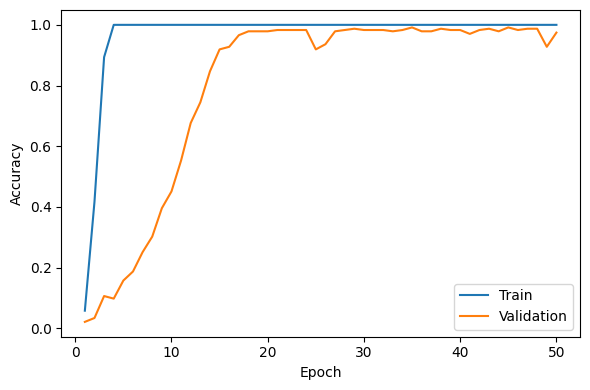

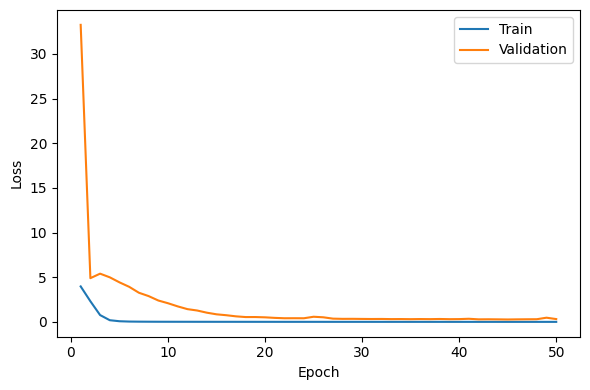

Best config id: 47 (val macro-F1 0.9914)


In [11]:
GRID_FOLDER = "input_sounds_cropped"   # second (25/key) dataset
RUN_GRID_SEARCH = True                  # set False to reuse an existing CSV

if RUN_GRID_SEARCH:
    Xg, yg, leg, (fb, tb, ncg) = load_dataset(GRID_FOLDER, samples_per_key=25, use_augment=True)
    yg_lab = np.argmax(yg, axis=1)

    # 60/20/20 stratified train/val/test.
    Xtv, Xte, ytv, yte, ytv_lab, yte_lab = train_test_split(
        Xg, yg, yg_lab, test_size=0.2, random_state=RANDOM_STATE, stratify=yg_lab)
    Xtr, Xval, ytr, yval = train_test_split(
        Xtv, ytv, test_size=0.25, random_state=RANDOM_STATE, stratify=ytv_lab)

    filter_options = [(32, 64), (64, 64), (64, 128)]
    dense_options = [128, 256]
    dropout_conv_options = [0.2]
    dropout_dense_options = [0.3, 0.4, 0.5]
    lr_options = [1e-3, 3e-4, 1e-4]

    search_space = list(product(filter_options, dense_options, dropout_conv_options,
                                dropout_dense_options, lr_options))
    print(f"Total configurations: {len(search_space)}")

    results, best_history, best_cfg_id, best_metric = [], None, None, -1.0
    for cfg_id, (filters, dunits, dconv, ddense, lr) in enumerate(search_space, start=1):
        model = build_cnn((fb, tb, 1), ncg, filters=filters, dense_units=dunits,
                          dropout_conv=dconv, dropout_dense=ddense, lr=lr)
        cb = [EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
        history = model.fit(Xtr, ytr, batch_size=32, epochs=50,
                            validation_data=(Xval, yval), verbose=0, callbacks=cb)

        yv = model.predict(Xval, verbose=0)
        yt = model.predict(Xte, verbose=0)
        row = {
            "config_id": cfg_id, "filters": str(filters), "dense_units": dunits,
            "dropout_conv": dconv, "dropout_dense": ddense, "lr": lr, "epochs": 50,
            "val_accuracy": float(np.mean(np.argmax(yval, 1) == np.argmax(yv, 1))),
            "val_macro_f1": f1_score(np.argmax(yval, 1), np.argmax(yv, 1), average="macro"),
            "val_top3_accuracy": top_k_accuracy(yval, yv, k=3),
            "test_accuracy": float(np.mean(np.argmax(yte, 1) == np.argmax(yt, 1))),
            "test_macro_f1": f1_score(np.argmax(yte, 1), np.argmax(yt, 1), average="macro"),
            "test_top3_accuracy": top_k_accuracy(yte, yt, k=3),
        }
        results.append(row)
        print(f"cfg {cfg_id:2d}/{len(search_space)} | {filters} d{dunits} "
              f"dd{ddense} lr{lr} | val_f1={row['val_macro_f1']:.4f}")
        if row["val_macro_f1"] > best_metric:
            best_metric, best_history, best_cfg_id = row["val_macro_f1"], history.history, cfg_id

    df = pd.DataFrame(results)
    df.to_csv("hyperparam_results.csv", index=False)
    print("\nSaved hyperparam_results.csv")
    print(df.sort_values("val_macro_f1", ascending=False).head())

    if best_history is not None:
        ep = range(1, len(best_history["accuracy"]) + 1)
        for key, ylabel, fname in [("accuracy", "Accuracy", "best_config_accuracy_vs_epochs.pdf"),
                                    ("loss", "Loss", "best_config_loss_vs_epochs.pdf")]:
            plt.figure(figsize=(6, 4))
            plt.plot(ep, best_history[key], label="Train")
            plt.plot(ep, best_history["val_" + key], label="Validation")
            plt.xlabel("Epoch"); plt.ylabel(ylabel); plt.legend(); plt.tight_layout()
            plt.savefig(fname); plt.show()
        print(f"Best config id: {best_cfg_id} (val macro-F1 {best_metric:.4f})")
else:
    print("Skipping grid search; will reuse existing hyperparam_results.csv.")

## 4. Base model - 5-fold CV + Top-k accuracy + entropy reduction

Trains the base ("generalised") CNN, runs stratified 5-fold cross-validation on
the train/val portion, then trains a final model on all train/val and evaluates
on an untouched test set. Reports Top-k accuracy (k=1..5) and entropy reduction,
and saves the model as `keystroke_cnn_model.keras` for transfer learning
(paper Sec. 3.6 / 4.2-4.4).bold text

In [12]:
def compute_entropy_reduction(y_pred_probs, k, num_classes):
    """Mean entropy (bits) of the normalised top-k probabilities and its reduction
    relative to a uniform prior over `num_classes`."""
    entropies = []
    for probs in y_pred_probs:
        top = probs[np.argsort(probs)[-k:]]
        top = top / np.sum(top)
        top = np.clip(top, 1e-10, 1.0)
        entropies.append(-np.sum(top * np.log2(top)))
    mean_entropy = float(np.mean(entropies))
    return mean_entropy, float(np.log2(num_classes) - mean_entropy)


def plot_topk_bar_chart(topk, output_path, title="Top-K Accuracy"):
    ks = list(range(1, 6))
    accs = [topk[k] for k in ks]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(ks, accs, color="steelblue", alpha=0.7, edgecolor="black", linewidth=1.5)
    for k, a in zip(ks, accs):
        ax.text(k, a + 0.01, f"{a:.3f}", ha="center", va="bottom", fontweight="bold")
    ax.set_xlabel("Top-K"); ax.set_ylabel("Accuracy"); ax.set_title(title)
    ax.set_xticks(ks); ax.set_ylim(0, 1.1); ax.grid(True, alpha=0.3, axis="y")
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.5)
    plt.tight_layout(); plt.savefig(output_path, format="pdf", bbox_inches="tight"); plt.show()


def plot_entropy_vs_topk(entropy_data, num_classes, output_path, title_suffix=""):
    ks = sorted(entropy_data.keys())
    mean_ent = [entropy_data[k][0] for k in ks]
    ent_red = [entropy_data[k][1] for k in ks]
    rnd = np.log2(num_classes)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.plot(ks, mean_ent, marker="o", color="steelblue", label="Top-K entropy")
    ax1.axhline(rnd, color="red", linestyle="--", label=f"Random ({rnd:.2f} bits)")
    ax1.set_xlabel("Top-K"); ax1.set_ylabel("Entropy (bits)")
    ax1.set_title("Entropy of Top-K predictions" + title_suffix); ax1.set_xticks(ks)
    ax1.grid(True, alpha=0.3); ax1.legend()
    ax2.plot(ks, ent_red, marker="s", color="green", label="Entropy reduction")
    ax2.axhline(0, color="red", linestyle="--", alpha=0.5)
    ax2.set_xlabel("Top-K"); ax2.set_ylabel("Entropy reduction (bits)")
    ax2.set_title("Information leakage" + title_suffix); ax2.set_xticks(ks)
    ax2.grid(True, alpha=0.3); ax2.legend()
    plt.tight_layout(); plt.savefig(output_path, format="pdf", bbox_inches="tight"); plt.show()


def read_best_config(csv_path="hyperparam_results.csv"):
    """Best config (by val macro-F1) from the grid-search CSV, or a sensible default."""
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        row = df.loc[df["val_macro_f1"].idxmax()]
        filters = tuple(int(x) for x in str(row["filters"]).strip("()").split(",") if x.strip())
        cfg = {"filters": filters, "dense_units": int(row["dense_units"]),
               "dropout_conv": float(row["dropout_conv"]),
               "dropout_dense": float(row["dropout_dense"]), "lr": float(row["lr"])}
        print("Using best config from CSV:", cfg)
        return cfg
    cfg = {"filters": (32, 64), "dense_units": 256, "dropout_conv": 0.2,
           "dropout_dense": 0.4, "lr": 1e-3}
    print("CSV not found; using paper config 13:", cfg)
    return cfg

In [ ]:
BASE_DATASET_FOLDER = "input-sounds/cropped_base"
SAMPLES_PER_KEY_BASE = None
N_SPLITS = 5
TEST_SIZE = 0.2
EPOCHS = 50
BATCH_SIZE = 32
PATIENCE = 5

os.makedirs("analysis_outputs", exist_ok=True)
# Paper Sec. 3.8 deliberately adopts config 13 over the higher-val-F1 grid
# winner, "balancing validation performance and test generalisation".
best_config = {"filters": (32, 64), "dense_units": 256, "dropout_conv": 0.2,
               "dropout_dense": 0.4, "lr": 1e-3}  # paper config 13
print("Using paper config 13:", best_config)

# Load with augmentation OFF so the held-out test set stays clean.
Xb, yb, le, (fb, tb, ncb) = load_dataset(
    BASE_DATASET_FOLDER, samples_per_key=SAMPLES_PER_KEY_BASE, use_augment=False)
yb_lab = np.argmax(yb, axis=1)

X_trainval, X_test, y_trainval, y_test, ytv_lab, yte_lab = train_test_split(
    Xb, yb, yb_lab, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=yb_lab)
print(f"trainval={X_trainval.shape[0]}  test={X_test.shape[0]}")

In [14]:
# ---- Stratified K-fold cross-validation on trainval ----
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
fold_topk = {k: [] for k in range(1, 6)}
fold_entropy = {k: [] for k in range(1, 6)}
fold_entropy_red = {k: [] for k in range(1, 6)}
fold_macro_f1 = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, ytv_lab), start=1):
    print(f"\n--- Fold {fold}/{N_SPLITS} ---")
    Xtr, Xval = X_trainval[tr_idx], X_trainval[val_idx]
    ytr, yval = y_trainval[tr_idx], y_trainval[val_idx]

    model = build_cnn((fb, tb, 1), ncb, **best_config)
    cb = [EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)]
    model.fit(Xtr, ytr, batch_size=BATCH_SIZE, epochs=EPOCHS,
              validation_data=(Xval, yval), verbose=0, callbacks=cb)

    probs = model.predict(Xval, verbose=0)
    fold_macro_f1.append(f1_score(np.argmax(yval, 1), np.argmax(probs, 1), average="macro"))
    for k in range(1, 6):
        fold_topk[k].append(top_k_accuracy(yval, probs, k))
        me, er = compute_entropy_reduction(probs, k, ncb)
        fold_entropy[k].append(me); fold_entropy_red[k].append(er)
    print(f"  macro-F1={fold_macro_f1[-1]:.4f}  top1={fold_topk[1][-1]:.4f}")

topk_cv = {k: float(np.mean(fold_topk[k])) for k in range(1, 6)}
entropy_cv = {k: (float(np.mean(fold_entropy[k])), float(np.mean(fold_entropy_red[k])))
              for k in range(1, 6)}
print(f"\nCV macro-F1: {np.mean(fold_macro_f1):.4f} +/- {np.std(fold_macro_f1):.4f}")
for k in range(1, 6):
    print(f"  Top-{k}: acc={topk_cv[k]:.4f}  red={entropy_cv[k][1]:.3f} bits")


--- Fold 1/5 ---
  macro-F1=1.0000  top1=1.0000

--- Fold 2/5 ---
  macro-F1=1.0000  top1=1.0000

--- Fold 3/5 ---
  macro-F1=1.0000  top1=1.0000

--- Fold 4/5 ---
  macro-F1=1.0000  top1=1.0000

--- Fold 5/5 ---
  macro-F1=1.0000  top1=1.0000

CV macro-F1: 1.0000 +/- 0.0000
  Top-1: acc=1.0000  red=6.066 bits
  Top-2: acc=1.0000  red=6.064 bits
  Top-3: acc=1.0000  red=6.063 bits
  Top-4: acc=1.0000  red=6.062 bits
  Top-5: acc=1.0000  red=6.062 bits


In [15]:
# ---- Final model on full trainval, evaluated on the untouched test set ----
final_model = build_cnn((fb, tb, 1), ncb, **best_config)
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_trainval, y_trainval, test_size=0.1, random_state=RANDOM_STATE, stratify=ytv_lab)
cb = [EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)]
history = final_model.fit(X_tr2, y_tr2, batch_size=BATCH_SIZE, epochs=EPOCHS,
                          validation_data=(X_val2, y_val2), verbose=1, callbacks=cb)

probs_test = final_model.predict(X_test, verbose=0)
topk_test = {k: top_k_accuracy(y_test, probs_test, k) for k in range(1, 6)}
entropy_test = {k: compute_entropy_reduction(probs_test, k, ncb) for k in range(1, 6)}
print("\nTest set:")
for k in range(1, 6):
    print(f"  Top-{k}: acc={topk_test[k]:.4f}  meanH={entropy_test[k][0]:.3f}  "
          f"red={entropy_test[k][1]:.3f} bits")

final_model.save("keystroke_cnn_model.keras")
print("\nSaved keystroke_cnn_model.keras")

Epoch 1/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.8041 - loss: 1.0482 - val_accuracy: 0.9075 - val_loss: 0.5609
Epoch 2/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 1.0000 - loss: 0.0324 - val_accuracy: 1.0000 - val_loss: 0.0477
Epoch 3/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 1.0000 - loss: 0.0118 - val_accuracy: 1.0000 - val_loss: 0.0143
Epoch 4/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 0.0088
Epoch 5/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0067
Epoch 6/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0061
Epoch 7/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0049
Epoch 8/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 1.0000 - loss: 0.0028 - val_acc

In [ ]:
# ---- Save Top-k / entropy results (CV + test) to CSV (no figures) ----
pd.DataFrame([{
    "top_k": k,
    "cv_accuracy_mean": topk_cv[k],
    "cv_mean_entropy_bits": entropy_cv[k][0],
    "cv_entropy_reduction_bits": entropy_cv[k][1],
    "test_accuracy": topk_test[k],
    "test_mean_entropy_bits": entropy_test[k][0],
    "test_entropy_reduction_bits": entropy_test[k][1],
} for k in range(1, 6)]).to_csv(
    "analysis_outputs/topk_entropy_results_cv_and_test.csv", index=False)
print("Saved analysis_outputs/topk_entropy_results_cv_and_test.csv")

> **Note — base model = idealised upper-bound reference (paper Sec. 4.3).** This
> 5-fold CV / held-out evaluation uses the large, homogeneous
> 125-samples-per-key dataset together with the paper's adopted **config 13**
> ((32,64) filters, 256 dense units, dropout 0.4, lr 1e-3). The paper presents it
> as *"an upper-bound performance reference ... an idealised scenario in which
> sufficient labelled data are available"* and attributes the very high accuracy
> (>99%) to the large, homogeneous, single-session data. Paper figures:
> Top-1 = 98.1%, Top-2 = 99.4%, Top-3 = 100%.
>
> Because every sample of a key comes from one continuous recording, this number
> reflects within-session separability, not cross-session generalisation. The
> realistic, limited-data result is the **transfer-learning** evaluation in
> Section 5, where the frozen backbone is fine-tuned on a different recording
> session with as few as 13 samples per key.

## 5. Transfer learning (paper Sec. 3.7 / 4.3)

Load the pretrained base model, freeze the convolutional backbone, attach a fresh
dense head and train only that head on a small, session-specific dataset. Reports
Top-1..5 accuracy on a held-out test set and saves `keystroke_transfer_model.keras`.

> To match the paper's two-dataset setup, point `TARGET_FOLDER` at the second
> (25/key) session and use a base model pretrained on the larger dataset. Here
> both default to `input_sounds_cropped` so the cell runs end-to-end.

In [17]:
def build_transfer_model_from_saved(saved_model_path, input_shape, new_num_classes,
                                    head_dense_units=128, head_dropout=0.3, lr=1e-3):
    """Freeze a saved model's conv backbone and attach a new dense classification head."""
    pretrained = load_model(saved_model_path)
    for layer in pretrained.layers:
        layer.trainable = False

    inputs = tf.keras.Input(shape=input_shape, name="tl_input")
    feature_model = tf.keras.Model(
        inputs=pretrained.layers[0].input if hasattr(pretrained.layers[0], "input") else inputs,
        outputs=pretrained.layers[-2].output, name="feature_extractor")
    features = feature_model(inputs, training=False)

    h = tf.keras.layers.Dense(head_dense_units, activation="relu", name="tl_dense")(features)
    h = tf.keras.layers.Dropout(head_dropout, name="tl_dropout")(h)
    outputs = tf.keras.layers.Dense(new_num_classes, activation="softmax", name="tl_softmax")(h)

    transfer_model = tf.keras.Model(inputs=inputs, outputs=outputs, name="transfer_model")
    transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                           loss="categorical_crossentropy", metrics=["accuracy"])
    return transfer_model

In [18]:
TARGET_FOLDER = "input_sounds_cropped"
SAVED_MODEL_PATH = "keystroke_cnn_model.keras"

Xt, yt, le_t, (fbt, tbt, nct) = load_dataset(TARGET_FOLDER, samples_per_key=25, use_augment=False)
yt_lab = np.argmax(yt, axis=1)

X_tv, X_te, y_tv, y_te, ytv_lab_t, _ = train_test_split(
    Xt, yt, yt_lab, test_size=0.2, train_size=0.8,
    random_state=RANDOM_STATE, stratify=yt_lab)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tv, y_tv, test_size=0.2, random_state=RANDOM_STATE, stratify=ytv_lab_t)
print(f"Train {X_tr.shape[0]} | Val {X_val.shape[0]} | Test {X_te.shape[0]}")

tl_model = build_transfer_model_from_saved(
    SAVED_MODEL_PATH, input_shape=(fbt, tbt, 1), new_num_classes=nct,
    head_dense_units=128, head_dropout=0.3, lr=1e-3)
tl_model.summary()

cb = [EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
hist_tl = tl_model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                       epochs=50, batch_size=32, verbose=1, callbacks=cb)

probs_tl = tl_model.predict(X_te, verbose=0)
print("\nTransfer-learning test accuracy:")
for k in range(1, 6):
    print(f"  Top-{k}: {top_k_accuracy(y_te, probs_tl, k):.4f}")

tl_model.save("keystroke_transfer_model.keras")
print("Saved keystroke_transfer_model.keras")

Loaded 1175 samples | shape (64, 50, 1) | 47 classes from input_sounds_cropped
Train 752 | Val 188 | Test 235


Model: "transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tl_input (InputLayer)           │ (None, 64, 50, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extractor (Functional)  │ (None, 256)            │    26,413,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_dense (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_dropout (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_softmax (Dense)              │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,452,207 (100.91 MB)

 Trainable params: 38,959 (152.18 KB)

 Non-trainable params: 26,413,248 (100.76 MB)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 240ms/step - accuracy: 0.0239 - loss: 3.9546 - val_accuracy: 0.0798 - val_loss: 3.6582
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0731 - loss: 3.6296 - val_accuracy: 0.2394 - val_loss: 3.4090
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1676 - loss: 3.3077 - val_accuracy: 0.4734 - val_loss: 3.0601
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2726 - loss: 2.9657 - val_accuracy: 0.6596 - val_loss: 2.6201
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3577 - loss: 2.6114 - val_accuracy: 0.7766 - val_loss: 2.1738
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4229 - loss: 2.3195 - val_accuracy: 0.8245 - val_loss: 1.7999
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4907 - loss: 2.0026 - val_accuracy: 0.8457 - val_loss: 1.4878
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5691 - loss: 1.7345 - val_accuracy: 0.8564 - 

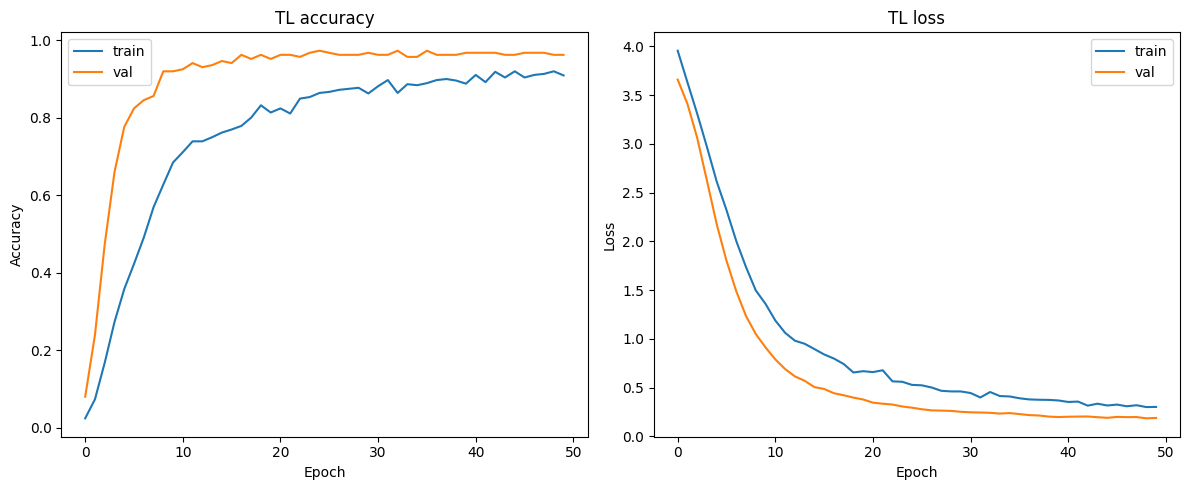

In [19]:
# Transfer-learning training curves (paper Figure 7).
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_tl.history["accuracy"], label="train")
plt.plot(hist_tl.history["val_accuracy"], label="val")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("TL accuracy")
plt.subplot(1, 2, 2)
plt.plot(hist_tl.history["loss"], label="train")
plt.plot(hist_tl.history["val_loss"], label="val")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("TL loss")
plt.tight_layout(); plt.savefig("curve_accuracy_TL.png", dpi=200); plt.show()

## 6. Test on unseen data

Crop a fresh recording into individual keystrokes and print the top-5 predictions
per click using the trained base model.

In [20]:
detectKeyPresses(len("diplomski123@"),
                "input-sounds/unseen_sound/diplomski123@.wav",
                "unseen_sounds_cropped", isUnseen=True)

In [21]:
def print_prediction(file_name, model, le):
    feat = extract_features(file_name, use_augment=False)
    feat = np.expand_dims(feat, axis=[0, -1])
    probs = model.predict(feat, verbose=0)
    pred = le.inverse_transform(np.argmax(probs, axis=1))
    print("Predicted class:", pred[0])
    print("Top 5 probabilities:")
    pairs = sorted(zip(le.classes_, probs[0]), key=lambda x: x[1], reverse=True)
    for label, p in pairs[:5]:
        print(f"  {label}: {p * 100:.4f}%")

In [23]:
# Predict the unseen typed text. Use the TRANSFER model (adapted to the
# input_sounds recording session) with its 47-key encoder `le_t` -- NOT the
# base model, whose 67-key alphabet contains modifier keys (control, option,
# tab, ...) that can never appear in typed text and whose recording session
# differs from the unseen clip.
try:
    unseen_model = tl_model
except NameError:
    unseen_model = load_model("keystroke_transfer_model.keras")

expected = ["d", "i", "p", "l", "o", "m", "s", "k", "i", "1", "2", "3", "@ (2 on US)"]
for i, key in enumerate(expected, start=1):
    path = f"unseen_sounds_cropped/unseen_{i}.wav"
    if os.path.exists(path):
        print(f"=== expected: {key} ===")
        print_prediction(path, unseen_model, le_t)
        print("-" * 50)

=== expected: d ===
Predicted class: d
Top 5 probabilities:
  d: 86.3681%
  ]: 7.4924%
  1: 2.3154%
  backSlash: 1.6451%
  m: 0.3521%
--------------------------------------------------
=== expected: i ===
Predicted class: p
Top 5 probabilities:
  p: 57.9987%
  i: 23.0323%
  j: 3.6876%
  o: 3.6335%
  u: 3.5742%
--------------------------------------------------
=== expected: p ===
Predicted class: p
Top 5 probabilities:
  p: 60.6312%
  i: 26.4173%
  o: 6.8710%
  L: 3.1068%
  k: 1.1578%
--------------------------------------------------
=== expected: l ===
Predicted class: L
Top 5 probabilities:
  L: 79.6293%
  i: 5.2510%
  zarez: 5.0772%
  j: 4.2116%
  p: 2.5504%
--------------------------------------------------
=== expected: o ===
Predicted class: 9
Top 5 probabilities:
  9: 28.0893%
  p: 20.5127%
  o: 16.0212%
  i: 12.8242%
  L: 7.3954%
--------------------------------------------------
=== expected: m ===
Predicted class: m
Top 5 probabilities:
  m: 27.8531%
  zarez: 25.1171%
  b: 1